In [12]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [13]:
cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="Target")

print("Dataset shape:", X.shape)
print("\nTarget classes:")
print(y.value_counts())

X.head()

Dataset shape: (569, 30)

Target classes:
Target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [14]:
print("Missing values:", X.isnull().sum().sum())
print("Duplicate rows:", X.duplicated().sum())

print("\nFeatures:", X.shape[1])
print("Samples:", X.shape[0])

Missing values: 0
Duplicate rows: 0

Features: 30
Samples: 569


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")


Feature scaling completed!


In [17]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [18]:
y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


In [19]:
y_proba = model.predict_proba(X_test_scaled)

probability_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability_Class_0": y_proba[:, 0],
    "Probability_Class_1": y_proba[:, 1]
})

probability_df.head(10)


,Actual,Predicted,Probability_Class_0,Probability_Class_1
0,0,0,1.000000,5.888242e-08
1,1,1,0.000011,9.999887e-01
2,0,0,0.993589,6.410825e-03
3,1,1,0.466491,5.335085e-01
4,0,0,1.000000,6.525001e-10
5,1,1,0.007840,9.921604e-01
6,1,1,0.000017,9.999828e-01
7,0,0,0.999999,5.635275e-07
8,0,0,0.999946,5.431637e-05
9,0,0,1.000000,8.041849e-11


In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Accuracy (%):", round(accuracy * 100, 2), "%")

Accuracy: 0.9825
Accuracy (%): 98.25 %


In [21]:
print("Classification Report")
print("----------------------")

print(classification_report(
    y_test,
    y_pred,
    target_names=cancer.target_names
))

Classification Report
----------------------
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Model Interpretation

Logistic Regression was used to classify breast cancer cases into two classes.

The dataset was divided into training and testing sets. Numerical features were standardized using StandardScaler before training the model.

The trained model generated predictions on unseen test data. Accuracy and the classification report were used to evaluate the model.

The predict_proba() function was also used to examine the probability assigned to each class.

Overall, Logistic Regression provides a simple and interpretable baseline classification model for this binary classification problem.

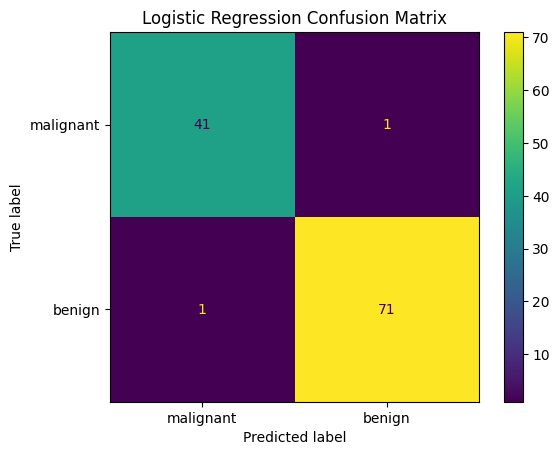

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=cancer.target_names
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()